In [5]:
# %%
import re
from difflib import SequenceMatcher
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Known placeholders (adjust if needed)
PLACEHOLDERS = {"NAME", "LOCATION", "EMAIL", "JOB", "MASKEDNUMBER",
                "URL", "USERNAME", "IP", "PASSWORD", "GENDER",
                "CREDITCARDNUMBER", "USERAGENT", "IBAN"}


In [6]:
# %%
def extract_masked_tokens(text, return_positions=False):
    """
    Extracts all tokens from text that match known placeholders.
    If return_positions is True, returns a list of (token, start, end) tuples.
    Otherwise, returns a list of token strings.
    """
    pattern = re.compile(r'\b(' + '|'.join(PLACEHOLDERS) + r')\b', re.IGNORECASE)
    if return_positions:
        return [(m.group(), m.start(), m.end()) for m in pattern.finditer(text)]
    return pattern.findall(text)

def map_gold_span_to_pred(gold, pred, g_start, g_end):
    """
    Maps a span (g_start, g_end) from the gold text to a corresponding span in the predicted text.
    Uses SequenceMatcher to align the texts. Returns (pred_start, pred_end) or (None, None) if mapping fails.
    """
    sm = SequenceMatcher(None, gold, pred)
    for tag, i1, i2, j1, j2 in sm.get_opcodes():
        if g_start >= i1 and g_start < i2 and g_end > i1 and g_end <= i2:
            return j1 + (g_start - i1), j1 + (g_end - i1)
    return None, None

def analyze_row(gold, pred):
    """
    For each token in the gold text, attempts to map and compare it in the predicted text.
    Returns a dictionary of counts: correct, misplaced, missing, false_positive.
    """
    valid_labels = {p.lower() for p in PLACEHOLDERS}
    metrics = {"correct": 0, "misplaced": 0, "missing": 0, "false_positive": 0}
    gold_tokens = extract_masked_tokens(gold, return_positions=True)
    
    # For each gold token, try to locate it in pred
    for g_token, g_start, g_end in gold_tokens:
        token_upper = g_token.upper()
        pred_span = map_gold_span_to_pred(gold, pred, g_start, g_end)
        if pred_span[0] is None or pred_span[1] is None or pred_span[0] < 0 or pred_span[1] > len(pred):
            metrics["missing"] += 1
            continue
        raw_pred = pred[pred_span[0]:pred_span[1]].strip()
        if raw_pred.upper() == token_upper:
            metrics["correct"] += 1
        else:
            metrics["misplaced"] += 1

    # Count extra tokens in pred that do not come from gold.
    pred_tokens = extract_masked_tokens(pred, return_positions=True)
    mapped = []
    for _, g_start, g_end in gold_tokens:
        span = map_gold_span_to_pred(gold, pred, g_start, g_end)
        if span[0] is not None and span[1] is not None:
            mapped.append(span)
    for p_token, p_start, p_end in pred_tokens:
        if not any(not (p_end < m[0] or p_start > m[1]) for m in mapped):
            metrics["false_positive"] += 1
    return metrics

def analyze_masking(df, original_col='original_text', gold_col='labeled_text', pred_col='masked_text'):
    """
    Applies the analysis row by row on the DataFrame.
    Returns a dictionary with aggregate metrics and a DataFrame of per-row metrics.
    """
    agg = {"correct": 0, "misplaced": 0, "missing": 0, "false_positive": 0}
    row_list = []
    
    for idx, row in df.iterrows():
        m = analyze_row(row[gold_col], row[pred_col])
        row_list.append(m)
        for key in agg:
            agg[key] += m.get(key, 0)
    
    per_row_df = pd.DataFrame(row_list)
    # Compute overall scores (for example, precision, recall, F1)
    TP = agg["correct"]
    FN = agg["missing"] + agg["misplaced"]
    FP = agg["false_positive"] + agg["misplaced"]
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0
    recall    = TP / (TP + FN) if (TP + FN) > 0 else 0
    F1        = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    
    return {"aggregate": agg, "per_row": per_row_df,
            "scores": {"precision": precision, "recall": recall, "F1": F1}}


In [7]:
# %%
# Adjust the filename as needed
data_file = "dataset_1.csv"  # The CSV should have columns: original_text, labeled_text, masked_text

# Load the evaluation data
df_eval = pd.read_csv(data_file)

# Run the masking analysis
results = analyze_masking(df_eval)

# Print aggregate metrics and computed scores
print("Aggregate Metrics:")
print(results["aggregate"])
print("\nEvaluation Scores:")
for score, value in results["scores"].items():
    print(f"{score.capitalize()}: {value*100:.2f}%")

# Optionally, save per-row metrics to a CSV file
results["per_row"].to_csv("masking_per_row_metrics.csv", index=False)


Aggregate Metrics:
{'correct': 8720, 'misplaced': 23, 'missing': 61, 'false_positive': 72}

Evaluation Scores:
Precision: 98.92%
Recall: 99.05%
F1: 98.98%


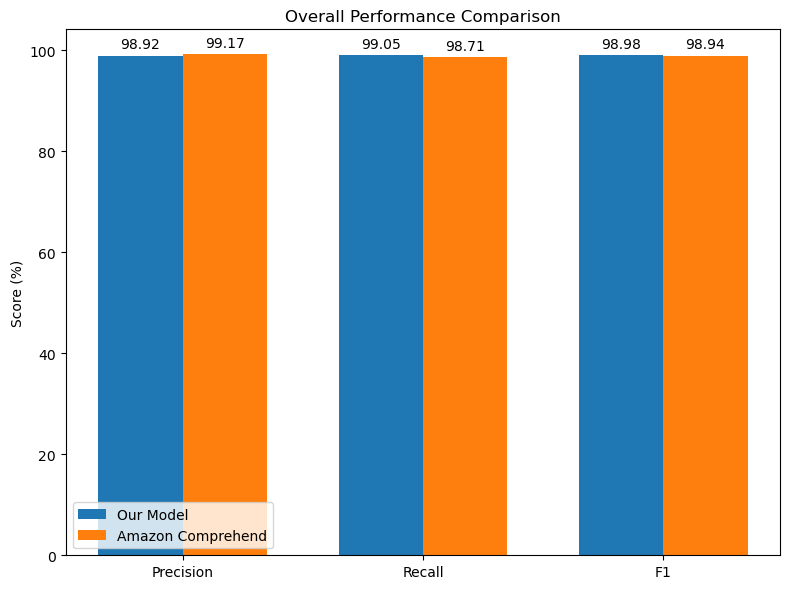

In [ ]:
# %%
def plot_overall_performance(metrics, our_scores, other_scores, other_label="Amazon Comprehend", output_file=None):
    """
    Plots overall performance metrics comparing our system with another.
    Parameters:
      - metrics: list of metric names (e.g., ["Precision", "Recall", "F1"]).
      - our_scores: list of our system scores (in percentage).
      - other_scores: list of scores for the other system.
      - other_label: label for the comparison system.
      - output_file: if provided, the plot is saved to this file.
    """
    x = np.arange(len(metrics))
    width = 0.35
    our_color = 'tab:blue'
    other_color = 'tab:orange'
    
    fig, ax = plt.subplots(figsize=(8, 6))
    bars_our = ax.bar(x - width/2, our_scores, width, label="Our Model", color=our_color)
    bars_other = ax.bar(x + width/2, other_scores, width, label=other_label, color=other_color)
    
    ax.set_ylabel("Score (%)")
    ax.set_title("Overall Performance Comparison")
    ax.set_xticks(x)
    ax.set_ylim(97, 100)
    ax.set_xticklabels(metrics)
    ax.legend()
    
    for bars in [bars_our, bars_other]:
        for bar in bars:
            ax.annotate(f'{bar.get_height():.2f}',
                        xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                        xytext=(0,3), textcoords="offset points",
                        ha='center', va='bottom')
    
    plt.tight_layout()
    if output_file:
        plt.savefig(output_file)
    plt.show()

# Our system scores (convert to percentages)
our_scores = [results["scores"]["precision"]*100,
              results["scores"]["recall"]*100,
              results["scores"]["F1"]*100]

# Results from Amazon Comprehend
amazon_scores = [99.17, 98.71, 98.94]

plot_overall_performance(["Precision", "Recall", "F1"], our_scores, amazon_scores, output_file="overall_performance.png")


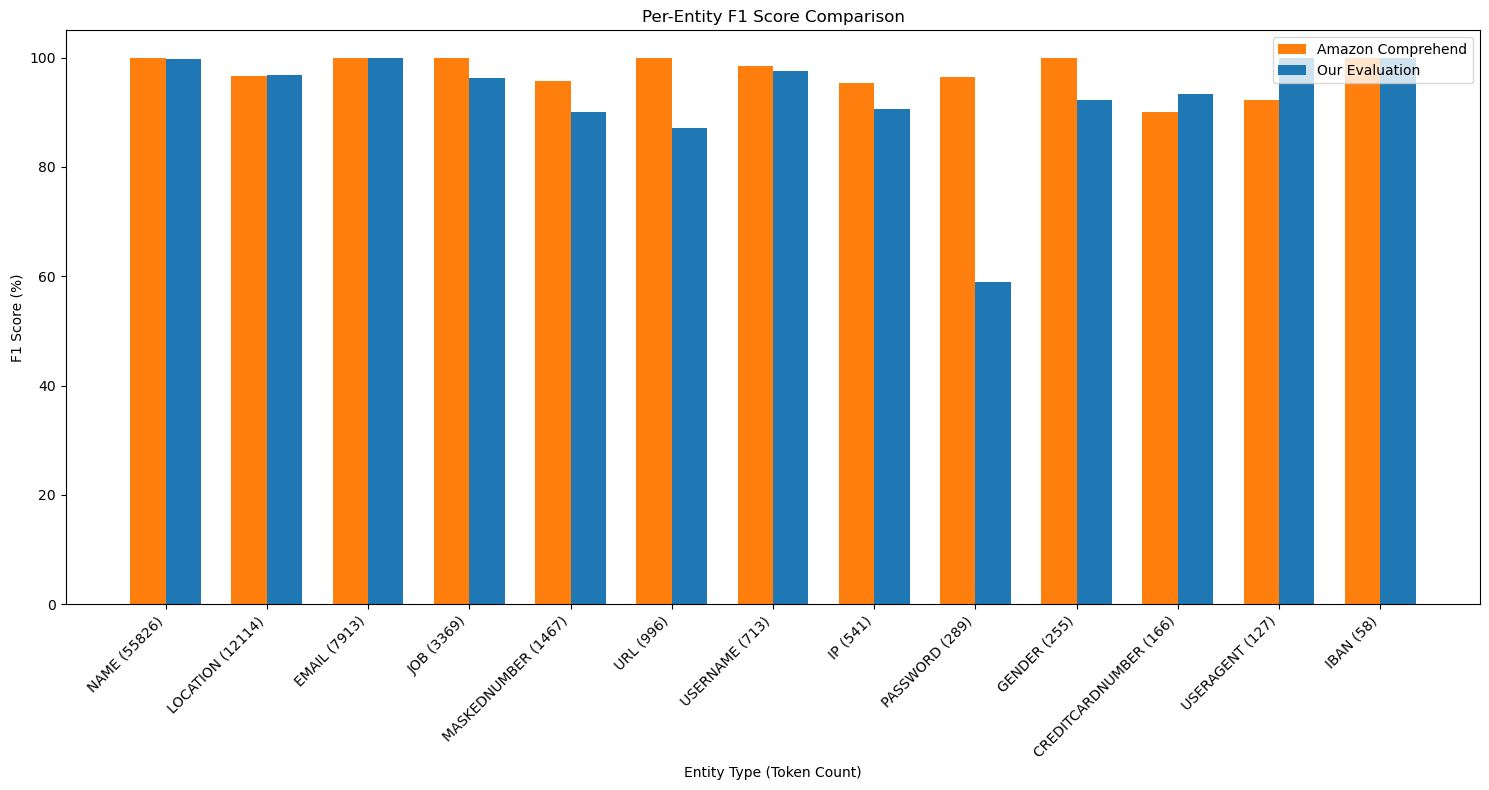

In [9]:
# %%
def plot_entity_f1(entity_types, amazon_f1, our_f1, token_counts, output_file=None):
    """
    Plots a per-entity F1 score comparison.
    
    Parameters:
      - entity_types: list of entity names.
      - amazon_f1: list of F1 scores for the reference system.
      - our_f1: list of F1 scores for our system.
      - token_counts: dict mapping each entity to its token count.
      - output_file: if provided, saves the plot to the given filename.
    """
    # Sort entities by token count (descending)
    sorted_entities = sorted(entity_types, key=lambda e: token_counts.get(e, 0), reverse=True)
    indices = [entity_types.index(e) for e in sorted_entities]
    amazon_sorted = [amazon_f1[i] for i in indices]
    our_sorted = [our_f1[i] for i in indices]
    labels = [f"{e} ({token_counts.get(e,0)})" for e in sorted_entities]
    
    x = np.arange(len(sorted_entities))
    width = 0.35
    fig, ax = plt.subplots(figsize=(15, 8))
    
    bars_amazon = ax.bar(x - width/2, amazon_sorted, width, label="Amazon Comprehend", color='tab:orange')
    bars_our = ax.bar(x + width/2, our_sorted, width, label="Our Evaluation", color='tab:blue')
    
    ax.set_xlabel("Entity Type (Token Count)")
    ax.set_ylabel("F1 Score (%)")
    ax.set_title("Per-Entity F1 Score Comparison")
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45, ha="right")
    ax.legend()
    
    plt.tight_layout()
    if output_file:
        plt.savefig(output_file)
    plt.show()

# Sample data for per-entity scores and token counts (adjust these with your actual data)
entity_types = ["CREDITCARDNUMBER", "EMAIL", "GENDER", "IBAN", "IP", "JOB", 
                "LOCATION", "MASKEDNUMBER", "NAME", "PASSWORD", "URL", "USERAGENT", "USERNAME"]

amazon_f1 = [90.00, 99.94, 100.00, 100.00, 95.41, 99.85, 96.60, 95.77, 99.86, 96.55, 100.00, 92.30, 98.55]
our_f1 = [93.30, 100.00, 92.30, 100.00, 90.60, 96.30, 96.80, 90.00, 99.70, 59.00, 87.20, 100.00, 97.50]
token_counts = {
    "NAME": 55826,
    "LOCATION": 12114,
    "EMAIL": 7913,
    "JOB": 3369,
    "MASKEDNUMBER": 1467,
    "URL": 996,
    "USERNAME": 713,
    "IP": 541,
    "PASSWORD": 289,
    "GENDER": 255,
    "CREDITCARDNUMBER": 166,
    "USERAGENT": 127,
    "IBAN": 58
}

plot_entity_f1(entity_types, amazon_f1, our_f1, token_counts, output_file="entity_f1_comparison.png")
